In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

plt.style.use("ggplot")

PROCESSED_PATH = Path("../data/processed")

In [2]:
customers = pd.read_csv(PROCESSED_PATH / "customers_clean.csv")
orders = pd.read_csv(PROCESSED_PATH / "orders_clean.csv")
order_items = pd.read_csv(PROCESSED_PATH / "order_items_clean.csv")
payments = pd.read_csv(PROCESSED_PATH / "payments_clean.csv")
products = pd.read_csv(PROCESSED_PATH / "products_clean.csv")
reviews = pd.read_csv(PROCESSED_PATH / "reviews_clean.csv")
sellers = pd.read_csv(PROCESSED_PATH / "sellers_clean.csv")

print("✅ All datasets loaded successfully!")

✅ All datasets loaded successfully!


In [3]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

print("✅ Date columns converted successfully!")

✅ Date columns converted successfully!


In [4]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Products:", products.shape)
print("Reviews:", reviews.shape)
print("Sellers:", sellers.shape)

Orders: (99441, 8)
Customers: (99441, 5)
Order Items: (112650, 7)
Payments: (103886, 5)
Products: (32951, 9)
Reviews: (99224, 7)
Sellers: (3095, 4)


In [5]:
# Extract year and month from purchase date
orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M")

# Count orders per month
monthly_orders = (
    orders.groupby("order_month")
    .size()
    .reset_index(name="Total Orders")
)

# Convert Period to string for plotting
monthly_orders["order_month"] = monthly_orders["order_month"].astype(str)

monthly_orders.head()

,order_month,Total Orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


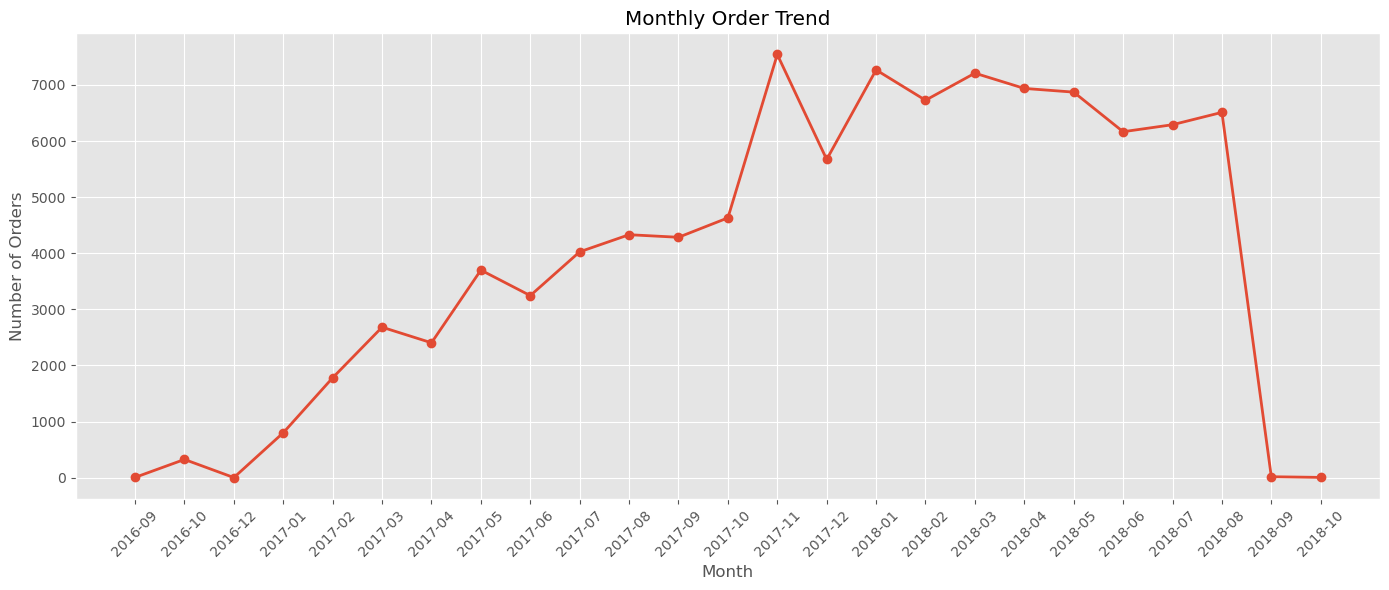

In [6]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_orders["order_month"],
    monthly_orders["Total Orders"],
    marker="o",
    linewidth=2
)

plt.xticks(rotation=45)
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

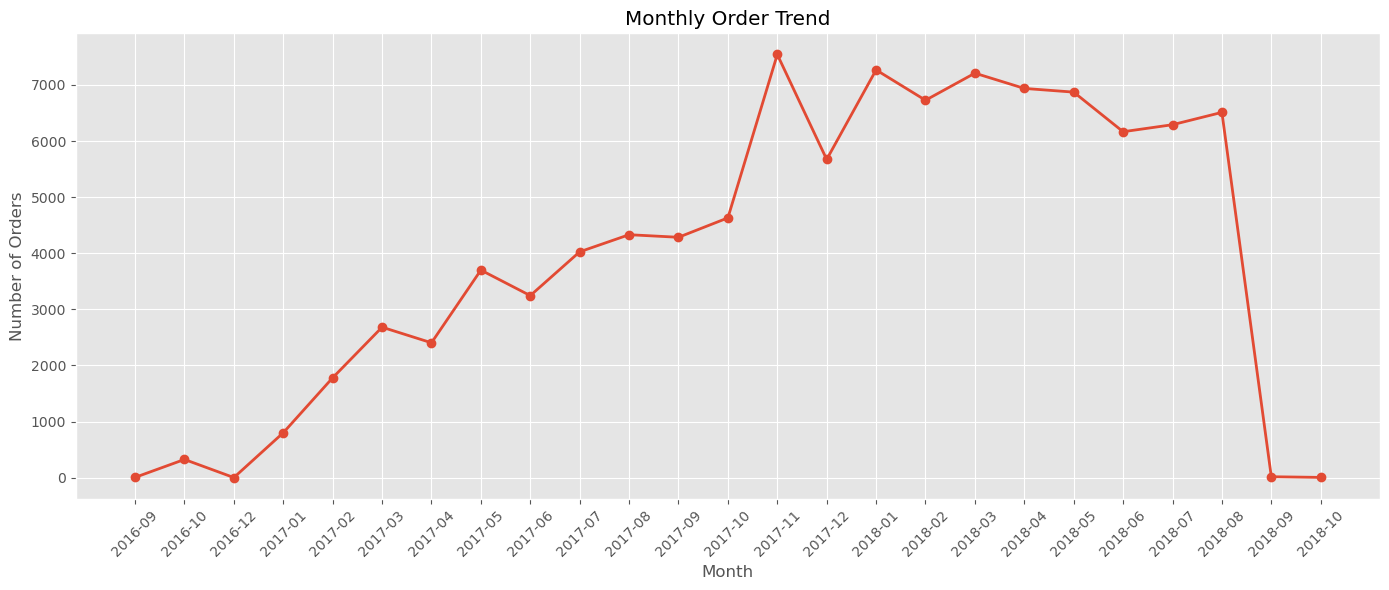

In [7]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_orders["order_month"],
    monthly_orders["Total Orders"],
    marker="o",
    linewidth=2
)

plt.xticks(rotation=45)
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    "../visuals/monthly_order_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
# Count each order status
order_status = (
    orders["order_status"]
    .value_counts()
    .reset_index()
)

order_status.columns = ["Order Status", "Count"]

order_status

,Order Status,Count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


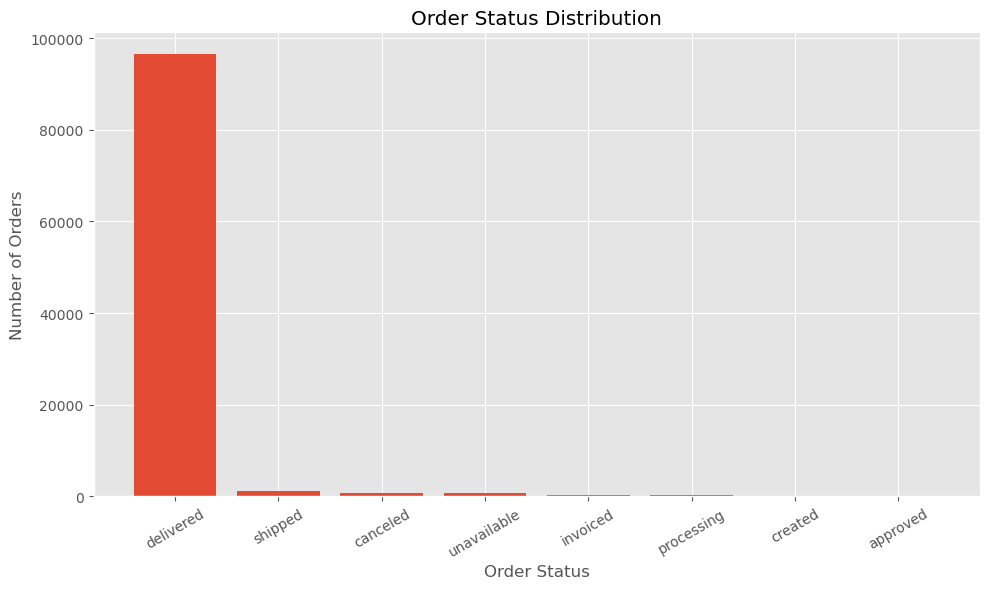

In [9]:
plt.figure(figsize=(10,6))

plt.bar(
    order_status["Order Status"],
    order_status["Count"]
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

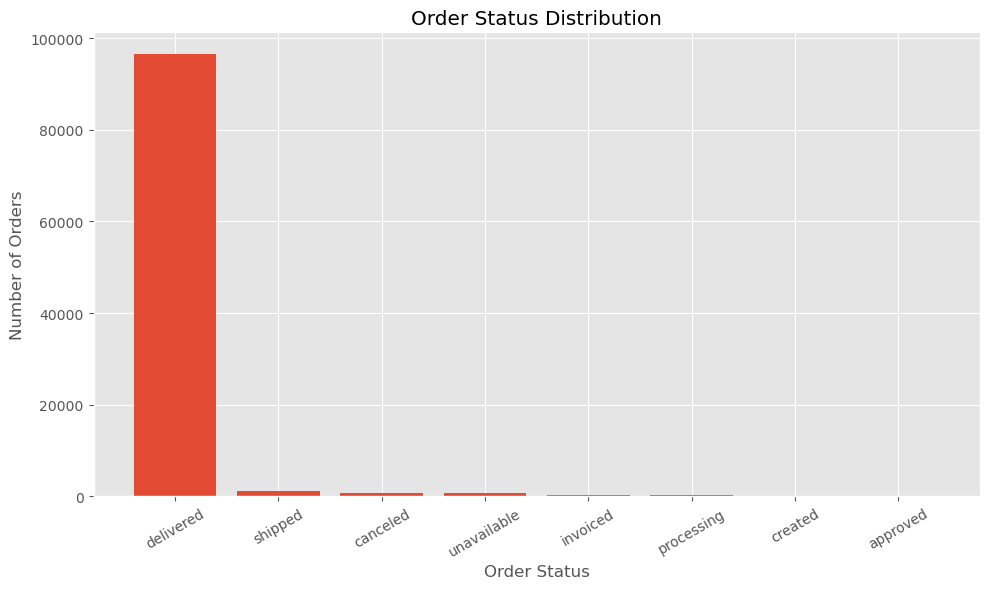

In [10]:
plt.figure(figsize=(10,6))

plt.bar(
    order_status["Order Status"],
    order_status["Count"]
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "../visuals/order_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
# Count payment method usage
payment_methods = (
    payments["payment_type"]
    .value_counts()
    .reset_index()
)

payment_methods.columns = ["Payment Method", "Transactions"]

payment_methods

,Payment Method,Transactions
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


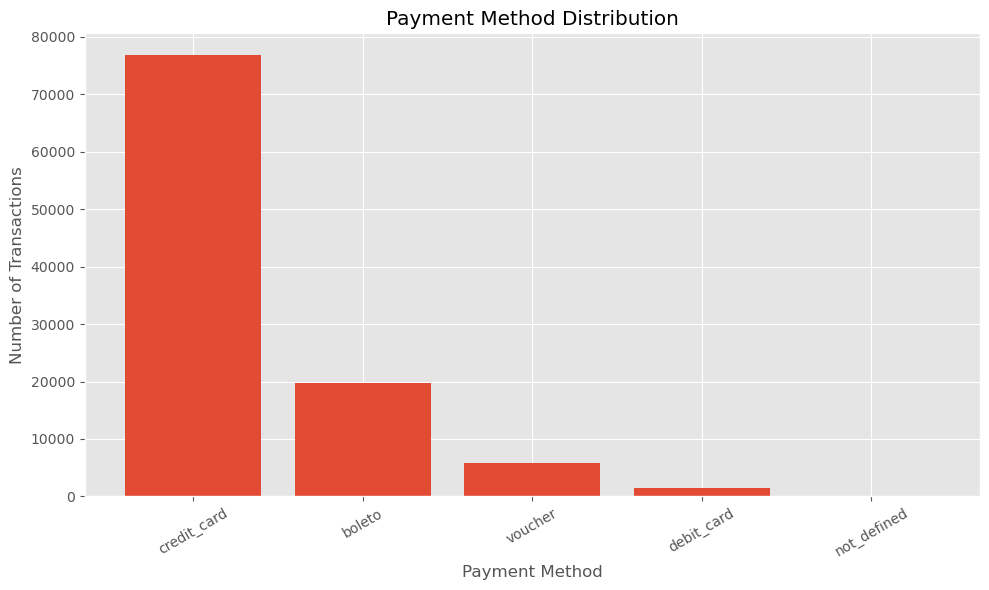

In [12]:
plt.figure(figsize=(10,6))

plt.bar(
    payment_methods["Payment Method"],
    payment_methods["Transactions"]
)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

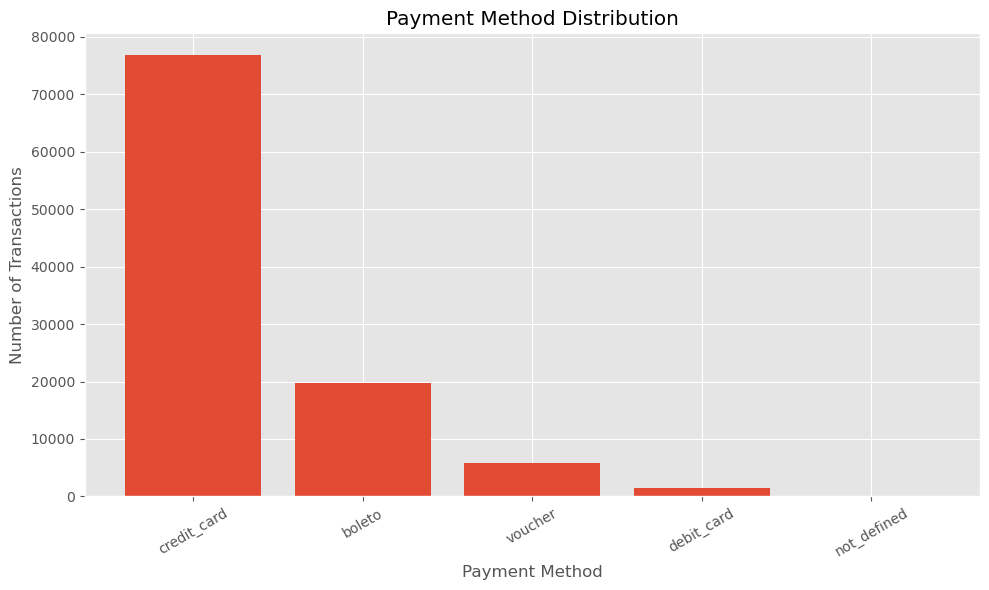

In [13]:
plt.figure(figsize=(10,6))

plt.bar(
    payment_methods["Payment Method"],
    payment_methods["Transactions"]
)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "../visuals/payment_method_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# Count review scores
review_scores = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

review_scores.columns = ["Review Score", "Count"]

review_scores

,Review Score,Count
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


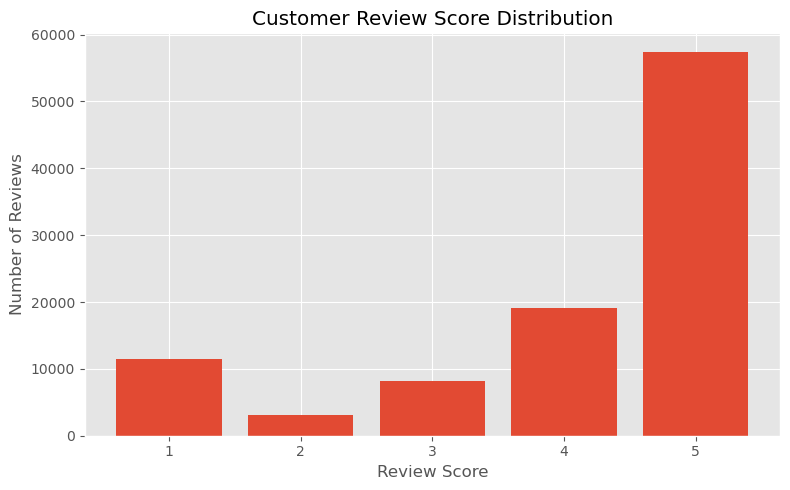

In [15]:
plt.figure(figsize=(8,5))

plt.bar(
    review_scores["Review Score"].astype(str),
    review_scores["Count"]
)

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

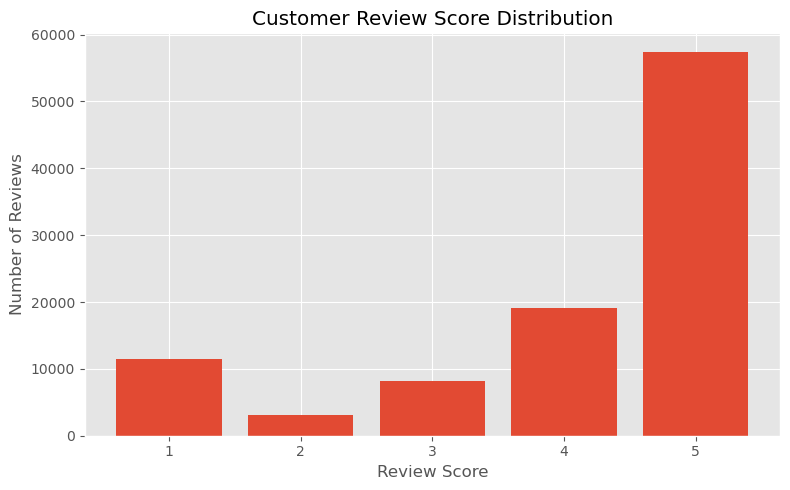

In [16]:
plt.figure(figsize=(8,5))

plt.bar(
    review_scores["Review Score"].astype(str),
    review_scores["Count"]
)

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.tight_layout()

plt.savefig(
    "../visuals/customer_review_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
# Merge order items with product information
product_sales = order_items.merge(
    products,
    on="product_id",
    how="left"
)

product_sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [18]:
category_sales = (
    product_sales["product_category_name"]
    .value_counts()
    .head(10)
    .reset_index()
)

category_sales.columns = [
    "Product Category",
    "Number of Products Sold"
]

category_sales

,Product Category,Number of Products Sold
0,cama_mesa_banho,11115
1,beleza_saude,9670
2,esporte_lazer,8641
3,moveis_decoracao,8334
4,informatica_acessorios,7827
5,utilidades_domesticas,6964
6,relogios_presentes,5991
7,telefonia,4545
8,ferramentas_jardim,4347
9,automotivo,4235


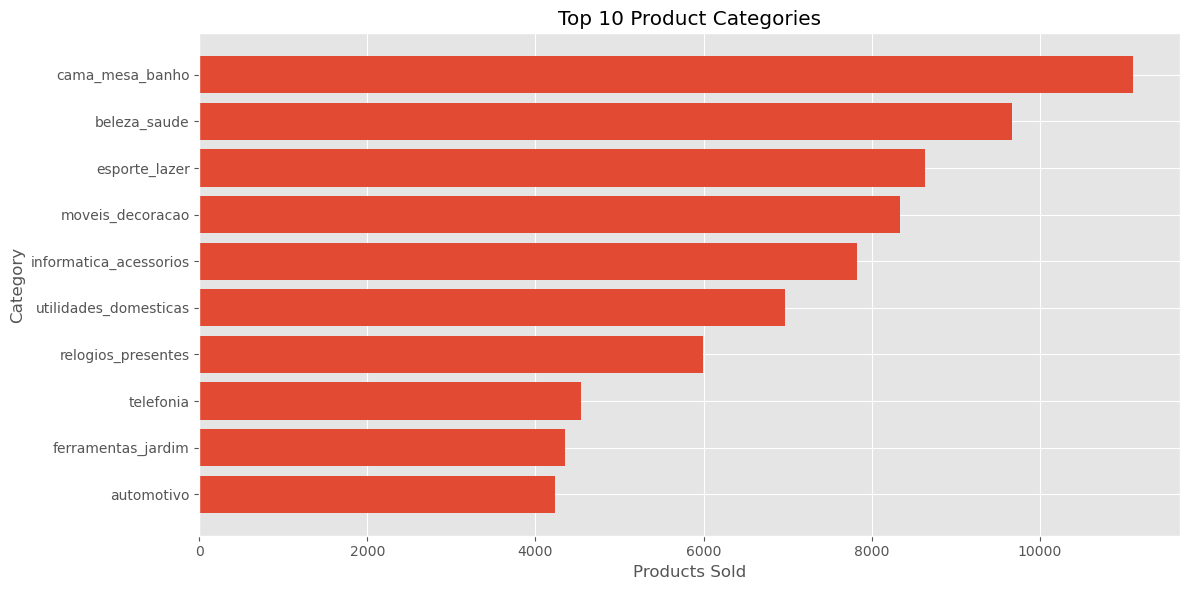

In [19]:
plt.figure(figsize=(12,6))

plt.barh(
    category_sales["Product Category"],
    category_sales["Number of Products Sold"]
)

plt.title("Top 10 Product Categories")
plt.xlabel("Products Sold")
plt.ylabel("Category")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

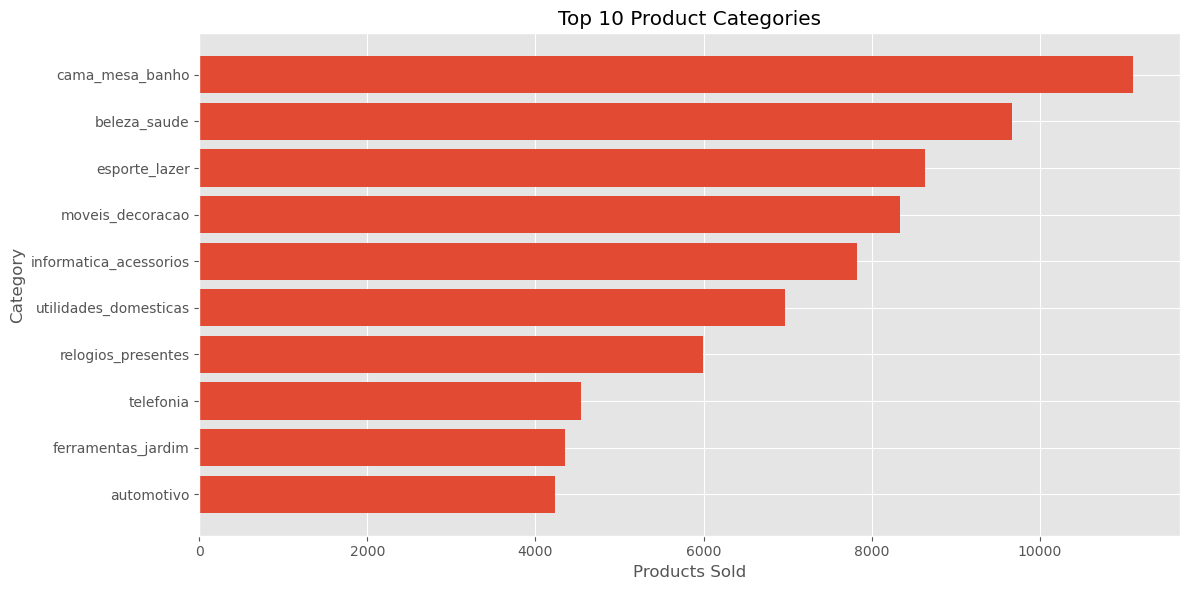

In [20]:
plt.figure(figsize=(12,6))

plt.barh(
    category_sales["Product Category"],
    category_sales["Number of Products Sold"]
)

plt.title("Top 10 Product Categories")
plt.xlabel("Products Sold")
plt.ylabel("Category")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../visuals/top_product_categories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# Merge order items with seller information
seller_performance = (
    order_items.groupby("seller_id")
    .agg(
        Products_Sold=("order_id", "count"),
        Total_Sales=("price", "sum")
    )
    .reset_index()
)

# Top 10 sellers
top_sellers = seller_performance.sort_values(
    by="Products_Sold",
    ascending=False
).head(10)

top_sellers

,seller_id,Products_Sold,Total_Sales
1235,6560211a19b47992c3666cc44a7e94c0,2033,123304.83
881,4a3ca9315b744ce9f8e9374361493884,1987,200472.92
368,1f50f920176fa81dab994f9023523100,1931,106939.21
2481,cc419e0650a3c5ba77189a1882b7556a,1775,104288.42
2643,da8622b14eb17ae2831f4ac5b9dab84a,1551,160236.57
1824,955fee9216a65b617aa5c0531780ce60,1499,135171.70
192,1025f0e2d44d7041d6cf58b6550e0bfa,1428,138968.55
1535,7c67e1448b00f6e969d365cea6b010ab,1364,187923.89
2836,ea8482cd71df3c1969d7b9473ff13abc,1203,37177.52
1505,7a67c85e85bb2ce8582c35f2203ad736,1171,141745.53


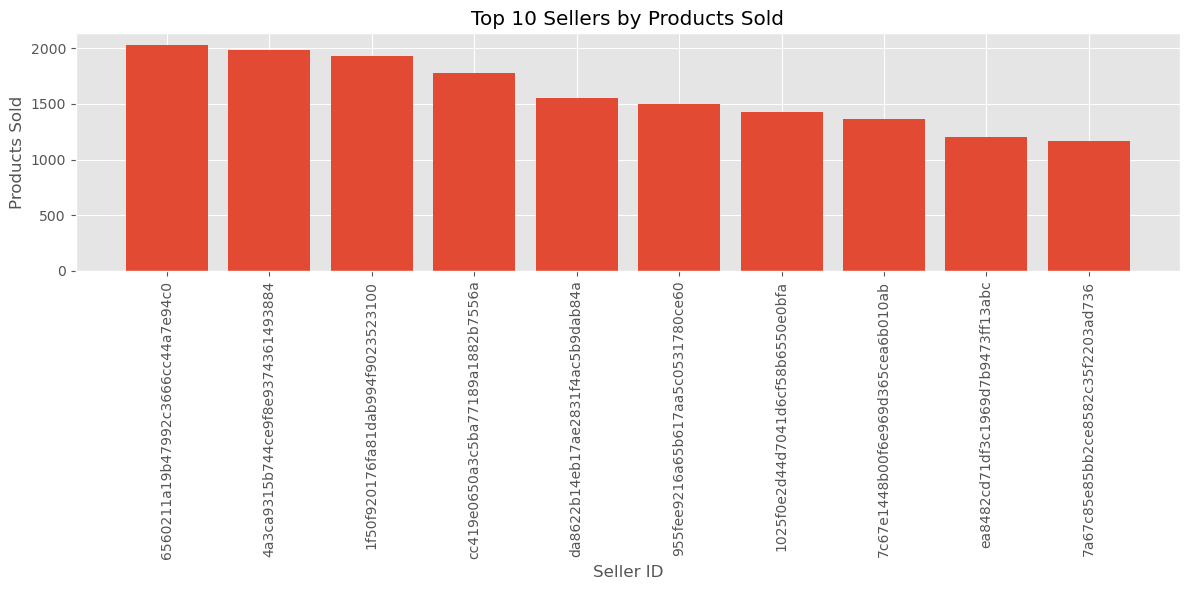

In [22]:
plt.figure(figsize=(12,6))

plt.bar(
    top_sellers["seller_id"],
    top_sellers["Products_Sold"]
)

plt.title("Top 10 Sellers by Products Sold")
plt.xlabel("Seller ID")
plt.ylabel("Products Sold")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

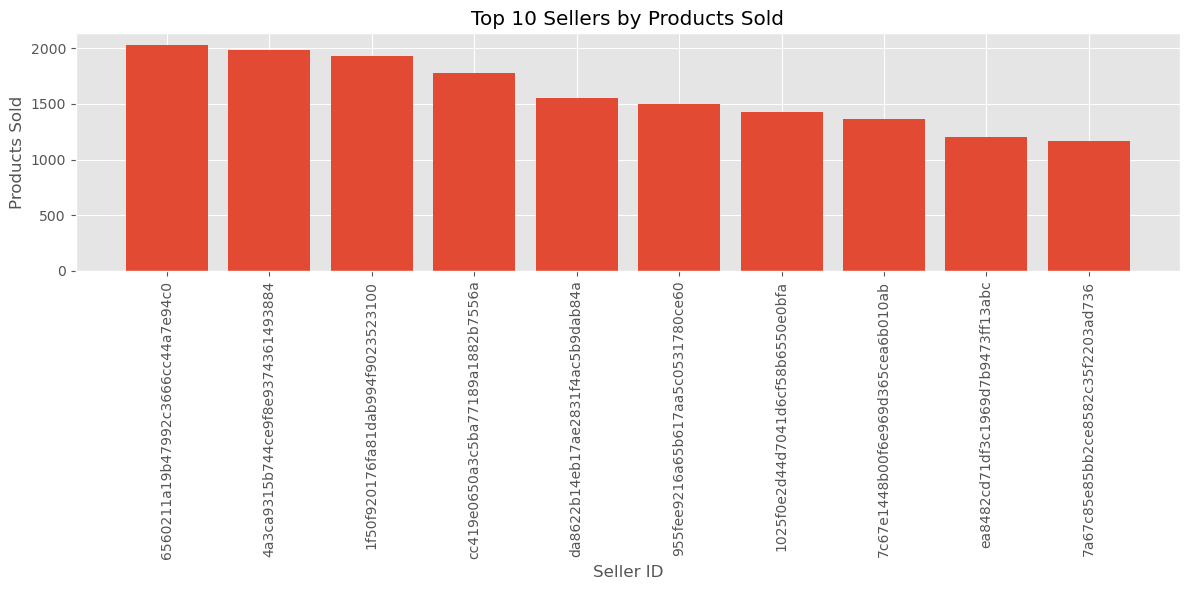

In [23]:
plt.figure(figsize=(12,6))

plt.bar(
    top_sellers["seller_id"],
    top_sellers["Products_Sold"]
)

plt.title("Top 10 Sellers by Products Sold")
plt.xlabel("Seller ID")
plt.ylabel("Products Sold")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../visuals/top_sellers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()